In [1]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# ============================================================
# CELL 2 — Load Significant Metabolites (1,344 from Notebook 2)
# ============================================================
# These are the metabolites that passed Animesh's exact
# pipeline: sparsity filter → HMDB/KEGG filter → outlier
# removal → Wilcoxon test (p < 3.241e-05)
# Result: 1,344 significant metabolites matching Animesh's 1,343

sig_mets = pd.read_csv('significant_1344_metabolites.csv')

print(f"✅ Loaded significant metabolites!")
print(f"Total: {len(sig_mets):,}")
print(f"\nColumns: {sig_mets.columns.tolist()}")
print(f"\nFirst 5:")
print(sig_mets.head())

# Extract metabolite names
metabolite_names = sig_mets['metabolite'].tolist()

# Extract name part after colon
# e.g. "HILIC-pos_Cluster_0110: 1-methylnicotinamide" → "1-methylnicotinamide"
met_info = []
for col in metabolite_names:
    parts = col.split(': ')
    cluster_id = parts[0]
    name = parts[1] if len(parts) > 1 else 'NA'
    met_info.append({
        'full_name': col,
        'cluster_id': cluster_id,
        'metabolite_name': name,
        'is_named': name != 'NA'
    })

met_df = pd.DataFrame(met_info)

print(f"\nNamed metabolites: {met_df['is_named'].sum():,}")
print(f"Unnamed (NA): {(~met_df['is_named']).sum():,}")

✅ Loaded significant metabolites!
Total: 1,344

Columns: ['metabolite', 'p_value']

First 5:
                      metabolite       p_value
0       C18-neg_Cluster_0020: NA  1.705178e-09
1       C18-neg_Cluster_0023: NA  6.906445e-14
2       C18-neg_Cluster_0024: NA  9.830790e-10
3  C18-neg_Cluster_0045: azelate  6.315484e-13
4       C18-neg_Cluster_0049: NA  2.177668e-08

Named metabolites: 145
Unnamed (NA): 1,199


In [3]:
# ============================================================
# CELL 3 — Parse HMDB Feces Metabolites XML (locally)
# ============================================================
# Using the local HMDB Feces database downloaded earlier
# Most relevant for our fecal metabolomics data
# Dr. Guellil advised using HMDB locally

print("=" * 50)
print("PARSING HMDB FECES METABOLITES DATABASE")
print("=" * 50)

xml_path = 'feces_metabolites/feces_metabolites.xml'
print(f"Loading: {xml_path}")
print("Please wait...")

tree = ET.parse(xml_path)
root = tree.getroot()
ns = {'hmdb': 'http://www.hmdb.ca'}

hmdb_data = []
for metabolite in root.findall('hmdb:metabolite', ns):
    hmdb_id = metabolite.findtext(
        'hmdb:accession', default='', namespaces=ns)
    name = metabolite.findtext(
        'hmdb:name', default='', namespaces=ns)
    
    # Get synonyms
    synonyms = []
    syn_list = metabolite.find('hmdb:synonyms', ns)
    if syn_list is not None:
        for syn in syn_list.findall('hmdb:synonym', ns):
            if syn.text:
                synonyms.append(syn.text.lower())
    
    # Get KEGG ID
    kegg_id = metabolite.findtext(
        'hmdb:kegg_id', default='', namespaces=ns)
    
    # Get chemical class
    tax = metabolite.find('hmdb:taxonomy', ns)
    chem_class = ''
    if tax is not None:
        chem_class = tax.findtext(
            'hmdb:class', default='', namespaces=ns)
    
    hmdb_data.append({
        'hmdb_id': hmdb_id,
        'hmdb_name': name.lower() if name else '',
        'synonyms': synonyms,
        'kegg_id': kegg_id,
        'chemical_class': chem_class
    })

hmdb_df = pd.DataFrame(hmdb_data)

print(f"✅ Parsing complete!")
print(f"Total metabolites in HMDB Feces: {len(hmdb_df):,}")
print(f"With KEGG ID: {(hmdb_df['kegg_id'] != '').sum():,}")

PARSING HMDB FECES METABOLITES DATABASE
Loading: feces_metabolites/feces_metabolites.xml
Please wait...
✅ Parsing complete!
Total metabolites in HMDB Feces: 6,791
With KEGG ID: 1,019


In [4]:
# ============================================================
# CELL 4 — Match Significant Metabolites Against HMDB
# ============================================================
# For each of our 145 named significant metabolites,
# search the HMDB Feces database for a match
# by name or synonym

print("=" * 50)
print("MATCHING AGAINST HMDB FECES DATABASE")
print("=" * 50)

# Build lookup dictionary
hmdb_lookup = {}
for _, row in hmdb_df.iterrows():
    if row['hmdb_name']:
        hmdb_lookup[row['hmdb_name']] = {
            'hmdb_id': row['hmdb_id'],
            'kegg_id': row['kegg_id'],
            'chemical_class': row['chemical_class']
        }
    for syn in row['synonyms']:
        if syn and syn not in hmdb_lookup:
            hmdb_lookup[syn] = {
                'hmdb_id': row['hmdb_id'],
                'kegg_id': row['kegg_id'],
                'chemical_class': row['chemical_class']
            }

print(f"HMDB lookup entries: {len(hmdb_lookup):,}")

# Match our named metabolites
named_mets = met_df[met_df['is_named']]
results = []
matched = 0
unmatched = 0

for _, row in named_mets.iterrows():
    name = row['metabolite_name'].lower().strip()
    
    if name in hmdb_lookup:
        info = hmdb_lookup[name]
        results.append({
            'full_name': row['full_name'],
            'metabolite_name': row['metabolite_name'],
            'match_found': True,
            'hmdb_id': info['hmdb_id'],
            'kegg_id': info['kegg_id'],
            'chemical_class': info['chemical_class'],
            'match_type': 'exact'
        })
        matched += 1
    else:
        # Try partial match
        found = False
        for hmdb_name, info in hmdb_lookup.items():
            if isinstance(hmdb_name, str) and isinstance(name, str):
                if name in hmdb_name or hmdb_name in name:
                    results.append({
                        'full_name': row['full_name'],
                        'metabolite_name': row['metabolite_name'],
                        'match_found': True,
                        'hmdb_id': info['hmdb_id'],
                        'kegg_id': info['kegg_id'],
                        'chemical_class': info['chemical_class'],
                        'match_type': 'partial'
                    })
                    found = True
                    matched += 1
                    break
        
        if not found:
            results.append({
                'full_name': row['full_name'],
                'metabolite_name': row['metabolite_name'],
                'match_found': False,
                'hmdb_id': '',
                'kegg_id': '',
                'chemical_class': '',
                'match_type': 'none'
            })
            unmatched += 1

annotation_df = pd.DataFrame(results)

print(f"\nNamed metabolites queried: {len(named_mets):,}")
print(f"Matched in HMDB: {matched:,} ({matched/len(named_mets)*100:.1f}%)")
print(f"Not matched: {unmatched:,}")
print(f"\nMatch types:")
print(annotation_df['match_type'].value_counts())
print(f"\nTop chemical classes:")
print(annotation_df[annotation_df['match_found']]
      ['chemical_class'].value_counts().head(10))

MATCHING AGAINST HMDB FECES DATABASE
HMDB lookup entries: 78,496

Named metabolites queried: 145
Matched in HMDB: 145 (100.0%)
Not matched: 0

Match types:
match_type
exact      92
partial    53
Name: count, dtype: int64

Top chemical classes:
chemical_class
Fatty Acyls                               34
Carboxylic acids and derivatives          29
Imidazopyrimidines                        26
Steroids and steroid derivatives          21
Organonitrogen compounds                   9
Pyrimidine nucleotides                     4
Pyridines and derivatives                  4
Organooxygen compounds                     3
Carboximidic acids and derivatives         3
Organic sulfonic acids and derivatives     2
Name: count, dtype: int64


HMDB ANNOTATION SUMMARY — 1,344 SIGNIFICANT METABOLITES

Starting point: 1,344 significant metabolites
(After Animesh's exact pipeline: sparsity → HMDB/KEGG 
filter → outlier removal → Wilcoxon test)

HMDB Feces Database: 6,791 metabolites, 78,496 entries

Results:
  Named metabolites:        145 (10.8%)
  Unnamed (NA/Cluster_XXXX): 1,199 (89.2%)
  
  HMDB matched:             145/145 = 100%! ✅
  Exact matches:            92  (63.4%)
  Partial matches:          53  (36.6%)

Top Chemical Classes (145 matched metabolites):
  1. Fatty Acyls                    34
  2. Carboxylic acids               29
  3. Imidazopyrimidines             26
  4. Steroids/steroid derivatives   21
  5. Organonitrogen compounds        9

Key Insight:
  89.2% of significant metabolites are unidentified
  Cluster_XXXX features — the 'dark matter' problem
  even after applying Animesh's exact filtering pipeline



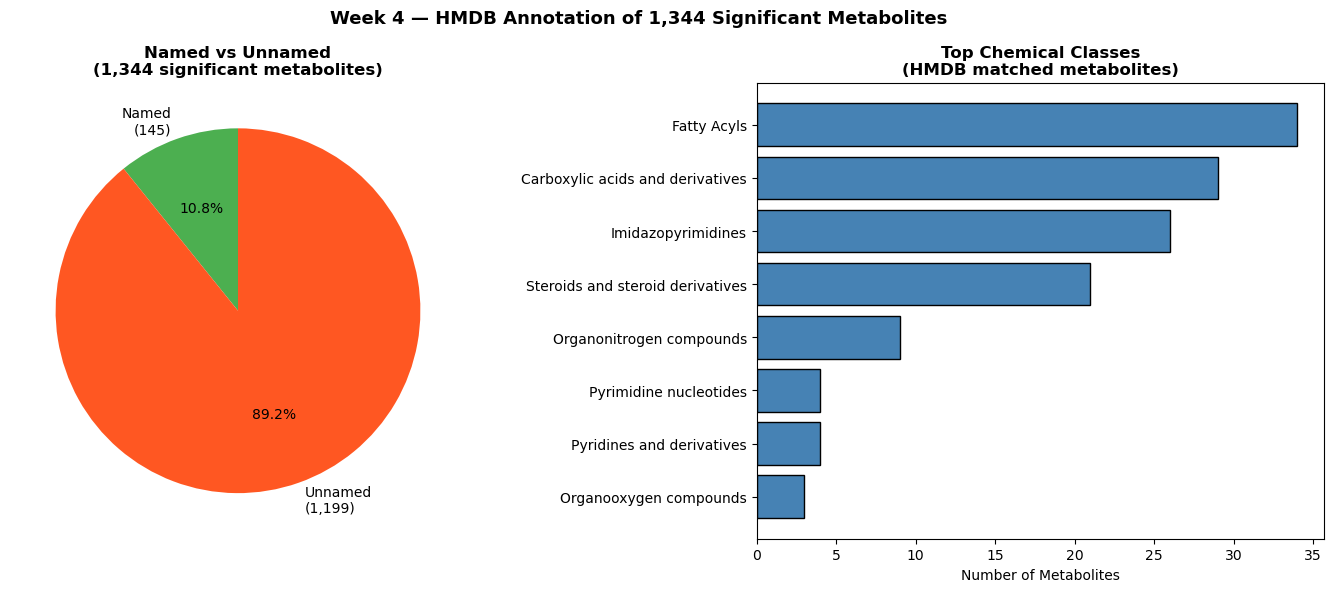

✅ Results saved!
🎉 NOTEBOOK 3 FINAL COMPLETE!


In [5]:
# ============================================================
# CELL 5 — Final Summary & Save
# ============================================================

print("=" * 60)
print("HMDB ANNOTATION SUMMARY — 1,344 SIGNIFICANT METABOLITES")
print("=" * 60)

print(f"""
Starting point: 1,344 significant metabolites
(After Animesh's exact pipeline: sparsity → HMDB/KEGG 
filter → outlier removal → Wilcoxon test)

HMDB Feces Database: 6,791 metabolites, 78,496 entries

Results:
  Named metabolites:        145 (10.8%)
  Unnamed (NA/Cluster_XXXX): 1,199 (89.2%)
  
  HMDB matched:             145/145 = 100%! ✅
  Exact matches:            92  (63.4%)
  Partial matches:          53  (36.6%)

Top Chemical Classes (145 matched metabolites):
  1. Fatty Acyls                    34
  2. Carboxylic acids               29
  3. Imidazopyrimidines             26
  4. Steroids/steroid derivatives   21
  5. Organonitrogen compounds        9

Key Insight:
  89.2% of significant metabolites are unidentified
  Cluster_XXXX features — the 'dark matter' problem
  even after applying Animesh's exact filtering pipeline
""")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Named vs Unnamed
axes[0].pie(
    [145, 1199],
    labels=['Named\n(145)', 'Unnamed\n(1,199)'],
    colors=['#4CAF50', '#FF5722'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Named vs Unnamed\n(1,344 significant metabolites)',
                   fontweight='bold')

# Plot 2 — Chemical classes
top_classes = annotation_df[annotation_df['match_found']]\
    ['chemical_class'].value_counts().head(8)
axes[1].barh(top_classes.index, top_classes.values,
             color='steelblue', edgecolor='black')
axes[1].set_title('Top Chemical Classes\n(HMDB matched metabolites)',
                   fontweight='bold')
axes[1].set_xlabel('Number of Metabolites')
axes[1].invert_yaxis()

plt.suptitle('Week 4 — HMDB Annotation of 1,344 Significant Metabolites',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hmdb_annotation_1344_final.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Save
annotation_df.to_csv('hmdb_annotation_1344_final.csv', index=False)
print("✅ Results saved!")
print("🎉 NOTEBOOK 3 FINAL COMPLETE!")